# BLOCO 0: Introdução

PyTorch é a biblioteca dominante em pesquisa de deep learning. O repositório que vamos seguir no projeto usa PyTorch. Os papers de LLMs publicam código em PyTorch. Conhecer bem os fundamentos aqui é investimento direto para o restante do projeto.

In [ ]:
import torch

print(torch.__version__)
print("GPU disponível:", torch.cuda.is_available())

2.10.0+cu128
GPU disponível: True


# BLOCO 1: Tensores

Um tensor é a estrutura de dados central do PyTorch. Pense nele como um array NumPy com dois superpoderes: roda em GPU e calcula gradientes automaticamente.
Antes de dominar qualquer rede neural, é preciso dominar tensores: shapes, operações, indexação.
Quase todo bug de deep learning é um bug de shape.

## Para comparar:

### * Listas Python

In [ ]:
array_python = [1,2,3,4]
array_python

[1, 2, 3, 4]

In [ ]:
type(array_python)

list

### * Arrays Numpy

In [ ]:
import numpy as np

array_numpy = np.random.rand(3,4)
array_numpy

array([[0.93789404, 0.93898191, 0.35427497, 0.44859008],
       [0.81943774, 0.33964586, 0.87486612, 0.48581833],
       [0.98299273, 0.42677897, 0.05377658, 0.05133598]])

In [ ]:
array_numpy[0][0] = 1
array_numpy

array([[1.        , 0.93898191, 0.35427497, 0.44859008],
       [0.81943774, 0.33964586, 0.87486612, 0.48581833],
       [0.98299273, 0.42677897, 0.05377658, 0.05133598]])

### * Tensor Pytorch

In [ ]:
tensor_pytorch = torch.randn(3,4)
tensor_pytorch

tensor([[ 2.5011, -1.6520,  1.2468, -1.3908],
        [-1.9053, -0.1769, -0.2685, -3.1746],
        [-1.4154,  0.6944, -0.1232, -0.1848]])

### * Criar tensores a partir de listas python ou NPArrays

In [ ]:
tensor_lista = torch.tensor(array_python)
tensor_lista

tensor([1, 2, 3, 4])

In [ ]:
tensor_array = torch.tensor(array_numpy)
tensor_array

tensor([[1.0000, 0.9390, 0.3543, 0.4486],
        [0.8194, 0.3396, 0.8749, 0.4858],
        [0.9830, 0.4268, 0.0538, 0.0513]], dtype=torch.float64)

### Outra forma

In [ ]:
tensor_copia = torch.from_numpy(array_numpy)

In [ ]:
tensor_copia

tensor([[1.0000, 0.9390, 0.3543, 0.4486],
        [0.8194, 0.3396, 0.8749, 0.4858],
        [0.9830, 0.4268, 0.0538, 0.0513]], dtype=torch.float64)

In [ ]:
# Do zero
t1 = torch.tensor([1.0, 2.0, 3.0])
t2 = torch.zeros(3, 4)
t3 = torch.ones(2, 3)
t4 = torch.rand(3, 3)       # uniforme [0, 1)
t5 = torch.randn(3, 3)      # normal com média 0, desvio 1

print(t1)
print(t2)
print(t3)
print(t4)
print(t5)
print(t2.shape)              # torch.Size([3, 4])
print(t4.dtype)              # float32 por padrão

tensor([1., 2., 3.])
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[0.6992, 0.5211, 0.8152],
        [0.2468, 0.6337, 0.3471],
        [0.5417, 0.7944, 0.6325]])
tensor([[ 1.7404,  0.2876,  0.5966],
        [ 0.3319, -0.8471,  0.8199],
        [ 1.6343,  1.5946,  0.8220]])
torch.Size([3, 4])
torch.float32


## Shape e Reshape

Shape é a informação mais importante de qualquer tensor. Quando algo dá errado numa rede neural, o primeiro lugar a olhar é o shape.

In [ ]:
tensor = torch.randn(4,3)
print(tensor.shape)
print(tensor.shape[0])
print(tensor.ndim)
tensor

torch.Size([4, 3])
4
2


tensor([[-1.2529,  0.9660, -1.1445],
        [ 0.6937,  0.4493, -2.1483],
        [-0.3418,  0.8646, -0.3746],
        [ 0.7852,  0.3721,  0.0129]])

In [ ]:
t_flat = tensor.view(12)
t_flat

tensor([-1.2529,  0.9660, -1.1445,  0.6937,  0.4493, -2.1483, -0.3418,  0.8646,
        -0.3746,  0.7852,  0.3721,  0.0129])

In [ ]:
t_col = tensor.view(12,1)
t_col

tensor([[-1.2529],
        [ 0.9660],
        [-1.1445],
        [ 0.6937],
        [ 0.4493],
        [-2.1483],
        [-0.3418],
        [ 0.8646],
        [-0.3746],
        [ 0.7852],
        [ 0.3721],
        [ 0.0129]])

In [ ]:
t_new = tensor.view(2,6)
t_new

tensor([[-1.2529,  0.9660, -1.1445,  0.6937,  0.4493, -2.1483],
        [-0.3418,  0.8646, -0.3746,  0.7852,  0.3721,  0.0129]])

In [ ]:
t_auto = tensor.view(4,-1)
t_auto

tensor([[-1.2529,  0.9660, -1.1445],
        [ 0.6937,  0.4493, -2.1483],
        [-0.3418,  0.8646, -0.3746],
        [ 0.7852,  0.3721,  0.0129]])

### Exercício
Criar um tensor de shape (6,4), transformar em um de shape (3,8) e outro com shape 24

In [ ]:
tensor = torch.randn(6,4)
tensor

tensor([[ 1.1953,  0.0821,  0.1240, -0.9946],
        [ 1.3357, -0.0358,  1.1061,  0.4577],
        [ 0.3120, -0.5345,  0.2027,  0.3892],
        [-2.2748, -0.4451, -1.4300, -1.5893],
        [ 1.4032, -1.9611,  0.7069, -0.3562],
        [-0.2064, -2.3059, -0.0885, -0.2549]])

In [ ]:
new = tensor.view(3,-1)
new

tensor([[ 1.1953,  0.0821,  0.1240, -0.9946,  1.3357, -0.0358,  1.1061,  0.4577],
        [ 0.3120, -0.5345,  0.2027,  0.3892, -2.2748, -0.4451, -1.4300, -1.5893],
        [ 1.4032, -1.9611,  0.7069, -0.3562, -0.2064, -2.3059, -0.0885, -0.2549]])

In [ ]:
newnew = tensor.view(24)
newnew

tensor([ 1.1953,  0.0821,  0.1240, -0.9946,  1.3357, -0.0358,  1.1061,  0.4577,
         0.3120, -0.5345,  0.2027,  0.3892, -2.2748, -0.4451, -1.4300, -1.5893,
         1.4032, -1.9611,  0.7069, -0.3562, -0.2064, -2.3059, -0.0885, -0.2549])

## Operações com tensores

In [ ]:
a = torch.tensor([[1,2],[3,4]])
b = torch.tensor([[5,6],[7,8]])

In [ ]:
a + b

tensor([[ 6,  8],
        [10, 12]])

In [ ]:
a * b

tensor([[ 5, 12],
        [21, 32]])

In [ ]:
a @ b

tensor([[19, 22],
        [43, 50]])

In [ ]:
torch.matmul(a,b)

tensor([[19, 22],
        [43, 50]])

### output = input @ weight.T + bias


In [ ]:
dog_input = torch.rand((784,4))
dog_input

tensor([[0.6552, 0.3926, 0.1332, 0.1314],
        [0.9793, 0.0723, 0.3656, 0.8846],
        [0.4055, 0.2398, 0.8326, 0.1718],
        ...,
        [0.7106, 0.3053, 0.3074, 0.2647],
        [0.3778, 0.0394, 0.6737, 0.6380],
        [0.0385, 0.3755, 0.2440, 0.9657]])

In [ ]:
weights = torch.randn((16, 4))
weights

tensor([[-1.7896,  1.0161, -0.0982, -0.5851],
        [-0.8333,  0.3959, -0.7087, -0.3771],
        [-0.9090,  0.5809, -0.3551,  0.7780],
        [ 1.3750, -0.8544,  0.3027,  0.8793],
        [ 1.1616,  0.3948, -0.6872,  2.2638],
        [ 0.2697,  0.6470, -1.9975,  0.6673],
        [ 1.8566,  1.2457,  2.6504,  0.3540],
        [ 1.1313, -0.2962, -0.5571, -2.3738],
        [-0.2961, -0.4458,  1.1084,  0.7835],
        [ 1.9313,  1.6397, -1.2141, -1.0353],
        [-1.6444, -0.4308, -0.7457, -0.6634],
        [ 1.0162, -1.0283, -1.6338, -0.7897],
        [ 0.3959,  0.6492,  0.7809, -0.0520],
        [-0.5401,  0.2159,  0.0548, -0.2506],
        [-0.2752,  0.9892, -0.6860, -0.3187],
        [-0.7868,  0.9575,  0.4366,  1.1820]])

In [ ]:
bias = torch.rand(16)
bias

tensor([0.2621, 0.6243, 0.5818, 0.1712, 0.7817, 0.4579, 0.2908, 0.1193, 0.9140,
        0.5477, 0.7711, 0.5857, 0.8630, 0.0035, 0.9837, 0.1253])

In [ ]:
output = dog_input @ weights.T
output

tensor([[-0.8637, -0.5345, -0.3126,  ..., -0.2947,  0.0748,  0.0738],
        [-2.2325, -1.3801, -0.2898,  ..., -0.7149, -0.7307,  0.5040],
        [-0.6642, -0.8978, -0.3913,  ..., -0.1646, -0.5003,  0.4772],
        ...,
        [-1.1465, -0.7889, -0.3718,  ..., -0.3673, -0.1888,  0.1803],
        [-1.0755, -1.0172, -0.0634,  ..., -0.3185, -0.7305,  0.7886],
        [-0.2764, -0.4205,  0.8478,  ..., -0.1684, -0.1142,  1.5771]])

In [ ]:
output_teste = output+bias
output_teste

tensor([[-0.6016,  0.0897,  0.2692,  ..., -0.2912,  1.0585,  0.1991],
        [-1.9705, -0.7558,  0.2920,  ..., -0.7114,  0.2531,  0.6293],
        [-0.4022, -0.2735,  0.1905,  ..., -0.1611,  0.4834,  0.6025],
        ...,
        [-0.8844, -0.1646,  0.2100,  ..., -0.3638,  0.7949,  0.3056],
        [-0.8134, -0.3929,  0.5183,  ..., -0.3150,  0.2532,  0.9140],
        [-0.0143,  0.2038,  1.4295,  ..., -0.1649,  0.8695,  1.7025]])

In [ ]:
bias_expanded = bias.unsqueeze(0).repeat(784,1)
bias_expanded

tensor([[0.2621, 0.6243, 0.5818,  ..., 0.0035, 0.9837, 0.1253],
        [0.2621, 0.6243, 0.5818,  ..., 0.0035, 0.9837, 0.1253],
        [0.2621, 0.6243, 0.5818,  ..., 0.0035, 0.9837, 0.1253],
        ...,
        [0.2621, 0.6243, 0.5818,  ..., 0.0035, 0.9837, 0.1253],
        [0.2621, 0.6243, 0.5818,  ..., 0.0035, 0.9837, 0.1253],
        [0.2621, 0.6243, 0.5818,  ..., 0.0035, 0.9837, 0.1253]])

In [ ]:
output = output + bias_expanded
output

tensor([[-0.6016,  0.0897,  0.2692,  ..., -0.2912,  1.0585,  0.1991],
        [-1.9705, -0.7558,  0.2920,  ..., -0.7114,  0.2531,  0.6293],
        [-0.4022, -0.2735,  0.1905,  ..., -0.1611,  0.4834,  0.6025],
        ...,
        [-0.8844, -0.1646,  0.2100,  ..., -0.3638,  0.7949,  0.3056],
        [-0.8134, -0.3929,  0.5183,  ..., -0.3150,  0.2532,  0.9140],
        [-0.0143,  0.2038,  1.4295,  ..., -0.1649,  0.8695,  1.7025]])

## Indexação

In [ ]:
t = torch.arange(12).view(3,4).float()
t

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

In [ ]:
t[0]

tensor([0., 1., 2., 3.])

In [ ]:
t[:,1]

tensor([1., 5., 9.])

In [ ]:
t[1,2]

tensor(6.)

In [ ]:
t[0:2, 1:3]

tensor([[1., 2.],
        [5., 6.]])

In [ ]:
mask = t > 5
t[mask]

tensor([ 6.,  7.,  8.,  9., 10., 11.])

# BLOCO 2: Autograd

Este é o bloco mais importante do workshop. Autograd é o mecanismo que torna o PyTorch diferente de NumPy.

Em Numpy, o cálculo dos gradientes é feito manualmente.

O que o PyTorch faz por baixo: cada operação que você executa em tensores com requires_grad=True é registrada num grafo computacional. Quando você chama .backward(), PyTorch percorre esse grafo de trás para frente e calcula os gradientes usando a regra da cadeia. O mesmo backpropagation que em Numpy é feito à mão.

## requires_grad e o grafo computacional

In [ ]:
# Não me importo em como esse tensor se comporta em relação aos gradientes
t = torch.tensor([2,3])
t.requires_grad

False

In [ ]:
t_grad = torch.tensor([2,3], requires_grad=True, dtype= float)
t_grad.requires_grad

True

In [ ]:
x = torch.tensor(3,requires_grad=True,dtype=float)
y = x**2

print(y)
print(y.grad_fn)

tensor(9., dtype=torch.float64, grad_fn=<PowBackward0>)


In [ ]:
y.backward()
x.grad

tensor(6., dtype=torch.float64)

## Grafo com múltiplas operações

Rede real, operações encadeadas

In [ ]:
x = torch.tensor(2,dtype=float,requires_grad=True)
w = torch.tensor(3,dtype=float,requires_grad=True)
b = torch.tensor(1,dtype=float,requires_grad=True)
target = torch.tensor(5,dtype=float)
z = x*w + b
loss = (z - target) ** 2 # MSE

print(f"z = {z.item()}")
print(f"loss = {loss.item()}")

z = 7.0
loss = 4.0


Calculem na mão:
loss = (wx + b - 5)²

∂loss/∂w = 2(wx + b - 5) · x = 2(7 - 5) · 2 = 8  ✓

∂loss/∂b = 2(wx + b - 5) · 1 = 2(7 - 5) = 4       ✓

In [ ]:
loss.backward()

print(f"∂loss/∂w = {w.grad.item()}")   # deve ser 8.0
print(f"∂loss/∂x = {x.grad.item()}")   # deve ser 12.0
print(f"∂loss/∂b = {b.grad.item()}")   # deve ser 4.0

∂loss/∂w = 8.0
∂loss/∂x = 12.0
∂loss/∂b = 4.0


## Acúmulo de gradientes

In [ ]:
x = torch.tensor(2.,requires_grad=True)

for i in range(3):
    y = x ** 2
    y.backward()
    print(f"Iteração {i}: x.grad = {x.grad}")

Iteração 0: x.grad = 4.0
Iteração 1: x.grad = 8.0
Iteração 2: x.grad = 12.0


cada .backward() soma ao gradiente existente, não sobrescreve. Isso é útil em alguns casos avançados, mas no loop de treinamento é um bug garantido se você esquecer de zerar.

In [ ]:
x = torch.tensor(2.,requires_grad=True)

for i in range(3):
    y = x ** 2
    y.backward()
    print(f"Iteração {i}: x.grad = {x.grad}")
    x.grad.zero_()

Iteração 0: x.grad = 4.0
Iteração 1: x.grad = 4.0
Iteração 2: x.grad = 4.0


no loop de treinamento com PyTorch, sempre chamamos optimizer.zero_grad() antes do .backward().

In [ ]:
# Também útil: torch.no_grad() para inferência
# Desliga o grafo computacional — mais rápido e usa menos memória

x = torch.tensor(2.0, requires_grad=True)

with torch.no_grad():
    y = x ** 2               # grafo não é construído
    print(y.requires_grad)   # False

# Usado na avaliação do modelo (validation loop)

False


# BLOCO 3: MLP em PYTORCH

## Definindo a arquitetura: nn.Module

In [ ]:
import torch.nn as nn # Neural Networks

class MLP(nn.Module):
  def __init__(self,input_dim, hidden_dim, output_dim):
    super().__init__()

    self.input_to_hidden = nn.Linear(input_dim, hidden_dim)
    self.hidden_to_output = nn.Linear(hidden_dim, output_dim)

    self.relu = nn.ReLU()

  def forward(self,x):
    x = self.input_to_hidden(x)
    x = self.relu(x)
    x = self.hidden_to_output(x)
    return x

In [ ]:
model = MLP(input_dim = 784, hidden_dim = 128, output_dim = 10)
model

MLP(
  (input_to_hidden): Linear(in_features=784, out_features=128, bias=True)
  (hidden_to_output): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)

In [ ]:
# Contando os parâmetros
total = sum(p.numel() for p in model.parameters())
print(f"Total de parâmetros: {total:,}")
# 784 x 128 (cada par neurônio x entrada gera um peso)
# + 128 (biases, um para cada neurônio)
# + 128 x 10 (cada par neurônio oculto, neurônio de saída gera um peso)
# + 10 (biases)

# 784*128 + 128 + 128*10 + 10 = 101770


Total de parâmetros: 101,770


In [ ]:
print(model.input_to_hidden.weight.shape)
print(model.input_to_hidden.bias.shape)
print(model.input_to_hidden.weight.requires_grad)

torch.Size([128, 784])
torch.Size([128])
True


## Forward pass e loss


CrossEntropyLoss no PyTorch já aplica softmax internamente — por isso o forward() retorna logits crus, sem softmax no final. Isso é diferente do que fizemos em NumPy, onde aplicamos softmax explicitamente. Não é um erro — é a convenção do PyTorch. Mais numericamente estável assim.

In [ ]:
# Dado fictício: batch de 32 imagens achatadas (28×28 = 784)
X = torch.randn(32, 784)
y = torch.randint(0, 10, (32,))   # labels: inteiros de 0 a 9

# Forward pass
logits = model(X)
print(logits.shape)               # torch.Size([32, 10])

# Função de perda
criterion = nn.CrossEntropyLoss()
loss = criterion(logits, y)
print(f"Loss: {loss.item():.4f}")

torch.Size([32, 10])
Loss: 2.3536


## Looping de treinamento completo

 40%|████      | 4/10 [00:00<00:00, 17.37it/s]

Epoch  1 | Loss: 2.3260
Epoch  2 | Loss: 1.7308
Epoch  3 | Loss: 1.2113
Epoch  4 | Loss: 0.6915


 80%|████████  | 8/10 [00:00<00:00, 16.67it/s]

Epoch  5 | Loss: 0.3411
Epoch  6 | Loss: 0.1697
Epoch  7 | Loss: 0.0956
Epoch  8 | Loss: 0.0628


100%|██████████| 10/10 [00:00<00:00, 16.30it/s]


Epoch  9 | Loss: 0.0444
Epoch 10 | Loss: 0.0335


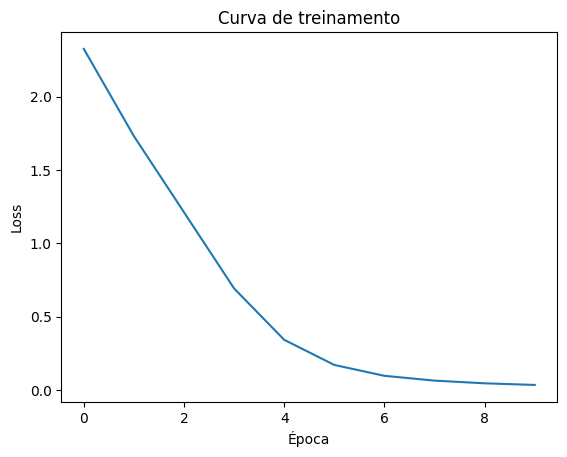

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt # Plotagem de gráficos, útil para visualizar o desempenho do modelo
from tqdm import tqdm

X_train = torch.randn(1000, 784)
y_train = torch.randint(0, 10, (1000,))

dataset = TensorDataset(X_train, y_train)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

model = MLP(784, 128, 10)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

losses = []

epochs = 10

for epoch in tqdm(range(epochs), total=epochs):
  epoch_loss = 0

  for X_batch, Y_batch in dataloader:

    logits = model(X_batch)

    loss = criterion(logits, Y_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()

  avg_loss = epoch_loss / len(dataloader)
  losses.append(avg_loss)
  print(f"Epoch {epoch+1:2d} | Loss: {avg_loss:.4f}")

plt.plot(losses)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de treinamento")
plt.show()